In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv("train.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
print(df.shape)
print(df.head())
print(df.info())

(1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008  

In [ ]:
missing = df.isnull().sum()
print(missing[missing > 0])

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [ ]:
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median(), inplace=True)
df.dropna(inplace=True)


/tmp/ipykernel_1202/3595103242.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median(), inplace=True)


In [ ]:
missing = df.isnull().sum()
print(missing[missing > 0])

Series([], dtype: int64)


In [ ]:
#Convert Text into numbers
df = pd.get_dummies(df, drop_first=True)
print(df.shape)

(0, 37)


In [ ]:
#Select important features
features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
X = df[features]
y = df['SalePrice']

In [ ]:
# Reload the original data
df = pd.read_csv("train.csv")

# Check the shape
print(f"Shape after reload: {df.shape}")  # Should be (1460, 81)

# Now use the improved cleaning approach (NO dropna)
# Fill numerical columns with median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)


Shape after reload: (1460, 81)


/tmp/ipykernel_1202/1699437255.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_1202/1699437255.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [ ]:
# Verify no missing values remain
print(f"Total missing values: {df.isnull().sum().sum()}")  # Should be 0


Total missing values: 0


In [ ]:
# Now proceed with encoding and splitting
df = pd.get_dummies(df, drop_first=True)
print(f"Shape after encoding: {df.shape}")  # Should be (1460, something)

# Select features
features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
X = df[features]
y = df['SalePrice']

print(f"X shape: {X.shape}")  # Should be (1460, 6)
print(f"y shape: {y.shape}")  # Should be (1460,)

Shape after encoding: (1460, 246)
X shape: (1460, 6)
y shape: (1460,)


In [ ]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")  # Should be 1168
print(f"Test set: {X_test.shape[0]} samples")      # Should be 292

Training set: 1168 samples
Test set: 292 samples


In [ ]:
print(y_train.head())
print(y_test.head())

254     145000
1066    178000
638      85000
799     175000
380     127000
Name: SalePrice, dtype: int64
892     154500
1105    325000
413     115000
522     159000
1036    315500
Name: SalePrice, dtype: int64


In [ ]:
from sklearn.model_selection \
   import train_test_split
X_train, X_test,y_train, y_test = \
   train_test_split(X, y,
   test_size=0.2,
   random_state=42)

In [ ]:
# Train the Linear Regression Model
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Train the model
model = LinearRegression()
model.fit(X_train_s, y_train)

# Predict on test set
y_pred = model.predict(X_test_s)

print('Training complete!')

Training complete!


In [ ]:
# Model Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Mean Squared Error (MSE): ${mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"R² Score: {r2:.4f}")

# Check model coefficients
feature_names = X.columns
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_
})
print("\nFeature Importance:")
print(coefficients.sort_values('Coefficient', ascending=False))

Mean Squared Error (MSE): $1,576,962,754.88
Root Mean Squared Error (RMSE): $39,710.99
Mean Absolute Error (MAE): $25,319.86
R² Score: 0.7944

Feature Importance:
       Feature   Coefficient
0  OverallQual  28034.034814
1    GrLivArea  27255.362251
2   GarageCars  11341.377587
3  TotalBsmtSF  10781.111106
5    YearBuilt  10759.780089
4     FullBath  -2963.657634


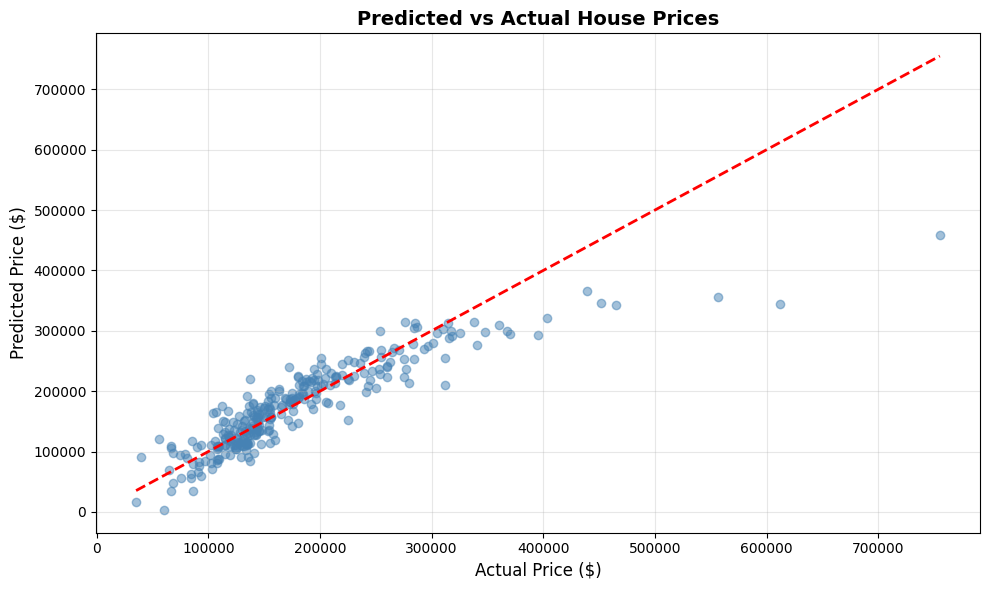

In [ ]:
# Plot 1: Predicted vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.title('Predicted vs Actual House Prices', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretation:
# Points close to the red line = accurate predictions
# Wide scatter from the line = prediction errors

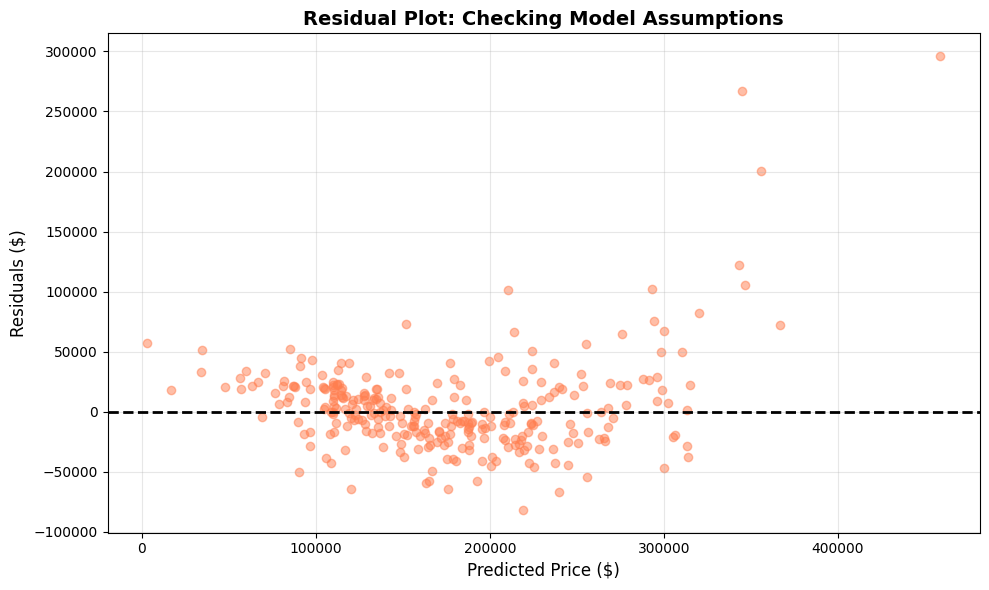

In [ ]:
# Plot 2: Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color='coral')
plt.axhline(0, color='black', linestyle='--', lw=2)
plt.xlabel('Predicted Price ($)', fontsize=12)
plt.ylabel('Residuals ($)', fontsize=12)
plt.title('Residual Plot: Checking Model Assumptions', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretation:
# Random scatter around 0 = healthy model
# Clear patterns = systematic bias in predictions

In [ ]:
X = train_df.drop("SalePrice", axis=1)
y = train_df["SalePrice"]


NameError: name 'train_df' is not defined